# Student Data Analysis Project

This notebook explores student academic performance using a real-world dataset. We'll load the data, perform some basic checks, and visualize key relationships.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [5]:
# Create requirements.txt for dependencies
libraries = [
    'pandas',
    'matplotlib',
    'seaborn'
]

with open('requirements.txt', 'w') as f:
    for lib in libraries:
        f.write(f'{lib}\n')

print("requirements.txt created successfully!")

# Display content of requirements.txt
with open('requirements.txt', 'r') as f:
    print("\nContent of requirements.txt:\n")
    print(f.read())

requirements.txt created successfully!

Content of requirements.txt:

pandas
matplotlib
seaborn



## 1. Data Loading

We'll fetch the 'Student Performance' dataset (specifically, student-mat.csv for mathematics students) from the UCI Machine Learning Repository. This dataset contains various attributes related to student performance in secondary education.

In [9]:
import io
import os
import pandas as pd

# Using the Student Performance data (Mathematics) from UCI Machine Learning Repository
dataset_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00356/student.zip'
zip_file_name = 'student.zip'
csv_file_name = 'student-mat.csv'

if not os.path.exists(csv_file_name):
    print(f"Downloading {zip_file_name}...")
    !wget {dataset_url}
    print("Extracting dataset...")
    !unzip -o {zip_file_name}

try:
    # Read as string to ensure correct parsing with sep=';'
    with open(csv_file_name, 'r') as f:
        content = f.read()
    df = pd.read_csv(io.StringIO(content), sep=';')
    print("Data loaded successfully!")
    display(df.head())
    print("\nDataFrame columns:")
    display(df.columns)
except FileNotFoundError:
    print(f"Error: The file '{csv_file_name}' was not found after download/extraction. Please check the URL or your connection.")
except Exception as e:
    print(f"An error occurred while loading the data: {e}")

Data loaded successfully!


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



DataFrame columns:


Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

## 2. Initial Data Inspection

Let's get a quick overview of the dataset: its structure, any missing values, and summary statistics.

In [ ]:
print("### Dataset Information ###")
df.info()

print("\n### Missing Values Count ###")
print(df.isnull().sum())

print("\n### Descriptive Statistics ###")
display(df.describe(include='all'))

### Dataset Information ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                               Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                               --------------  ----- 
 0   school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3  395 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB

### Missing Values Count ###
school;sex;age;address;fams

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
count,395
unique,395
top,"MS;""M"";19;""U"";""LE3"";""T"";1;1;""other"";""at_home"";..."
freq,1


## 3. Exploratory Data Analysis (EDA)

Time to dig into the data with some visualizations to find patterns and relationships. We'll save these plots for your GitHub repo.

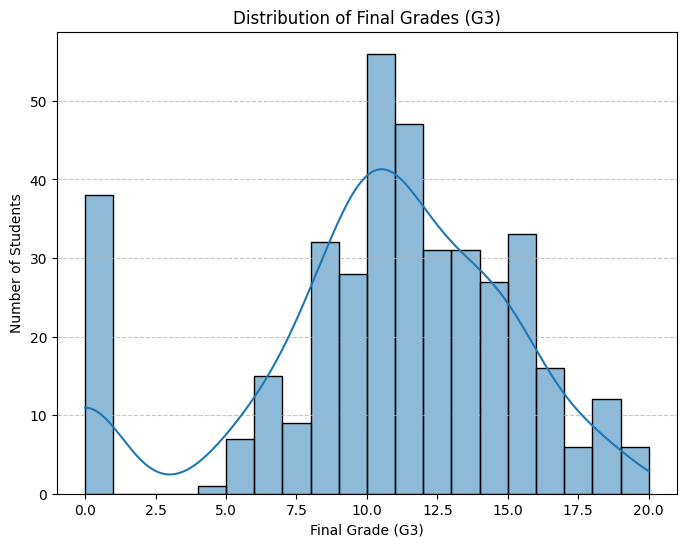

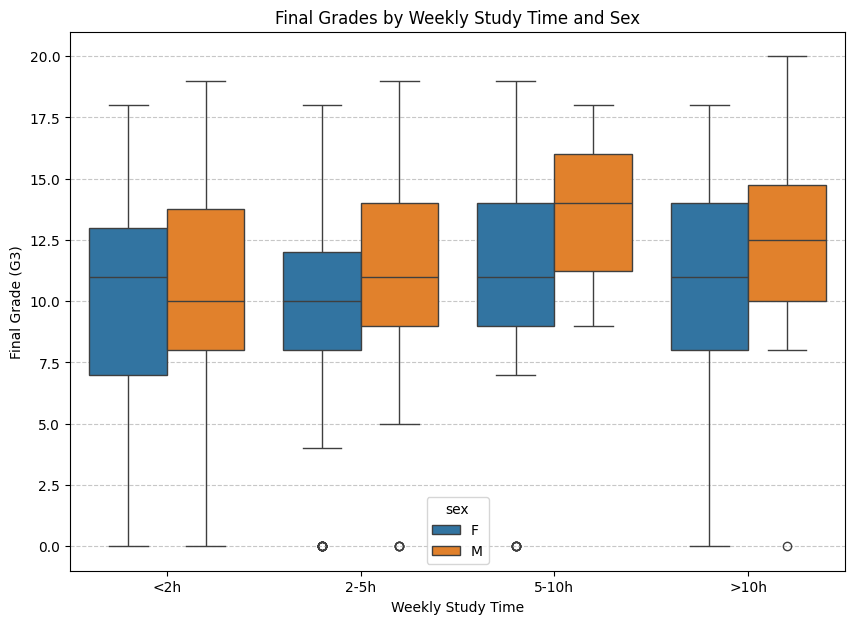

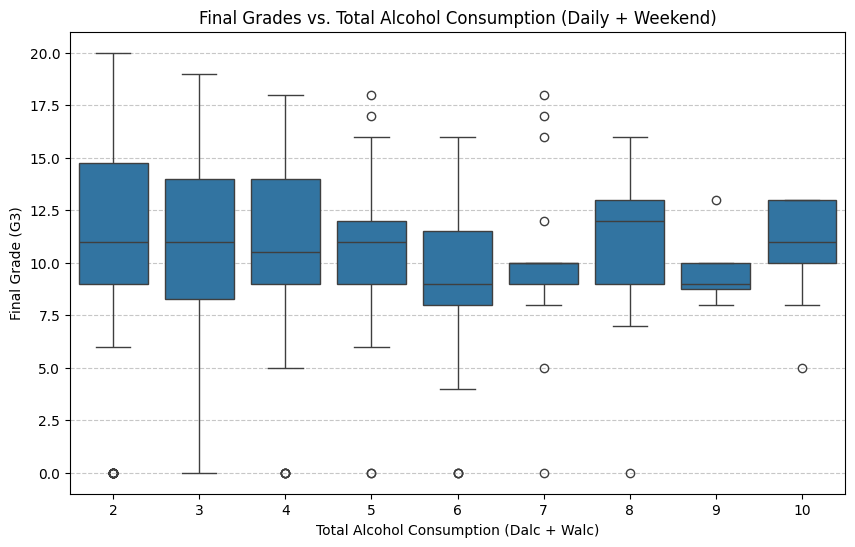

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

image_dir = 'images'
if not os.path.exists(image_dir):
    os.makedirs(image_dir)
    print(f"Created directory: {image_dir}")

# Plot 1: Distribution of Final Grades (G3)
plt.figure(figsize=(8, 6))
sns.histplot(df['G3'], kde=True, bins=20)
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(image_dir, 'G3_distribution.png'))
plt.show()

# Plot 2: Impact of Study Time on Final Grades, by Sex
plt.figure(figsize=(10, 7))
# Map studytime (1-4) to descriptive labels
df['studytime_label'] = df['studytime'].map({1: '<2h', 2: '2-5h', 3: '5-10h', 4: '>10h'})
sns.boxplot(x='studytime_label', y='G3', hue='sex', data=df, order=['<2h', '2-5h', '5-10h', '>10h'])
plt.title('Final Grades by Weekly Study Time and Sex')
plt.xlabel('Weekly Study Time')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(image_dir, 'studytime_vs_G3_by_sex.png'))
plt.show()

# Plot 3: Alcohol Consumption vs. Final Grades
# Dalc: daily alcohol consumption (1-5), Walc: weekend alcohol consumption (1-5)
df['total_alc'] = df['Dalc'] + df['Walc']
plt.figure(figsize=(10, 6))
sns.boxplot(x='total_alc', y='G3', data=df)
plt.title('Final Grades vs. Total Alcohol Consumption (Daily + Weekend)')
plt.xlabel('Total Alcohol Consumption (Dalc + Walc)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(image_dir, 'alcohol_vs_G3.png'))
plt.show()

## 4. Next Steps

This analysis gives us a good starting point. To take this project further, you could:

*   **Feature Engineering**: Create new features from existing ones (e.g., total grade from G1, G2, G3).
*   **Correlation Matrix**: Explore correlations between all numerical features.
*   **Machine Learning**: Build a model to predict final grades based on other student attributes.
*   **More Visualizations**: Dive deeper into other interesting variables like 'failures', 'absences', or 'romantic' relationships.

All plots generated in this notebook are saved in the `images` directory, ready for your GitHub repository!